In [1]:
import open3d as o3d
import numpy as np
import json
from pathlib import Path
from glob import glob
from PIL import Image
import cv2
import networkx as nx
import matplotlib.pyplot as plt
import random

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


# 1. Load the full mesh

In [2]:
# scene_dir = 'ScanNet_Data/data/56a0ec536c'
import os
# Change the scene: c9abde4c4b - toilet
# scene: 285efbc7cf - kitchen
scene_dir = 'ScanNet_Data/data/0a7cc12c0e'

# Change the scene: 0a7cc12c0e - bedroom
# scene_dir = 'ScanNet_Data/data/0a7cc12c0e'
mesh_file = scene_dir + '/scans/mesh_aligned_0.05_semantic.ply'
segments_file = scene_dir + '/scans/segments.json'
anno_file = scene_dir + '/scans/segments_anno.json'
output_dir = scene_dir + '/extracted_individual_objects'
os.makedirs(output_dir, exist_ok=True)
colmap_dir = os.path.join(scene_dir, 'dslr/colmap')
image_dir = os.path.join(scene_dir, 'dslr/resized_images')
region_crop_dir = scene_dir + '/region_crops'
os.makedirs(region_crop_dir, exist_ok=True)
region_dir = scene_dir + '/regions'
os.makedirs(region_dir, exist_ok=True)
region_top5_dir = os.path.join(scene_dir, 'region_cropped_top5')
os.makedirs(region_top5_dir, exist_ok=True)

In [3]:
mesh = o3d.io.read_triangle_mesh(mesh_file)
vertices = np.asarray(mesh.vertices)
triangles = np.asarray(mesh.triangles)
segment_ids = np.asarray(json.load(open(segments_file))['segIndices'])
anno_data = np.asarray(json.load(open(anno_file))['segGroups'])

# 2. Extract Individual Objects

In [4]:
segment_to_object = {}
object_to_label = {}
for object in anno_data:
    object_id = object['objectId']
    label = object['label']
    segments = object['segments']
    for segment_id in segments:
        segment_to_object[segment_id] = object_id
    object_to_label[object_id] = label

In [5]:
unique_instances = set(segment_to_object.values())
print(f'There are {len(unique_instances)} unique instances.')

There are 140 unique instances.


obj -> label

obj -> mesh

obj -> centroid

In [7]:
object_to_centroid = {}
for i, file in enumerate(os.listdir(output_dir)):
    mesh = o3d.io.read_triangle_mesh(os.path.join(output_dir, file))
    vertices = mesh.vertices
    triangles = mesh.triangles
    centroid = np.mean(vertices, axis=0)
    object_to_centroid[i] = centroid

In [8]:
from sklearn.cluster import DBSCAN
object_ids = list(object_to_centroid.keys())
centroids = np.array([object_to_centroid[obj_id] for obj_id in object_to_centroid])

In [29]:
# TODO: adjust the params of dbscan
'''
dbscan = DBSCAN(eps=0.8, min_samples=4)
regions = dbscan.fit_predict(centroids)
object_to_regions = {obj_id : region_id for obj_id, region_id in zip(object_ids, regions)}
'''

'\ndbscan = DBSCAN(eps=0.8, min_samples=4)\nregions = dbscan.fit_predict(centroids)\nobject_to_regions = {obj_id : region_id for obj_id, region_id in zip(object_ids, regions)}\n'

/home/vlm_caption/.local/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/home/vlm_caption/.local/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/home/vlm_caption/.local/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/home/vlm_caption/.local/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/home/vlm_caption/.local/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/home/vlm_caption/.local/lib/p

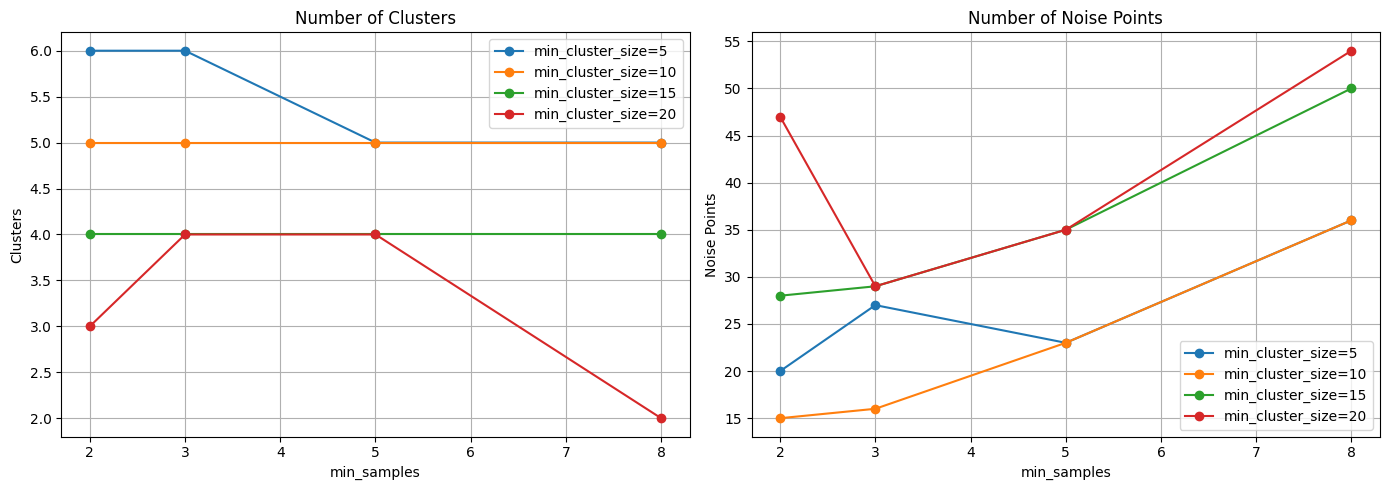

In [36]:
import numpy as np
import hdbscan
import matplotlib.pyplot as plt
from itertools import product

# 假设你已经有：
# object_to_centroid = {obj_id: centroid (np.array[3,])}
object_ids = list(object_to_centroid.keys())
centroids = np.array([object_to_centroid[obj_id] for obj_id in object_ids])

# 🔧 设置参数范围
min_cluster_sizes = [5, 10, 15, 20]
min_samples_list = [2, 3, 5, 8]

results = []

# 遍历参数组合
for min_cluster_size, min_samples in product(min_cluster_sizes, min_samples_list):
    clusterer = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size,
                                 min_samples=min_samples)
    labels = clusterer.fit_predict(centroids)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)

    results.append({
        'min_cluster_size': min_cluster_size,
        'min_samples': min_samples,
        'n_clusters': n_clusters,
        'n_noise': n_noise
    })

# 🎨 可视化聚类数与噪声点数
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 聚类数
for min_cluster_size in min_cluster_sizes:
    y = [r['n_clusters'] for r in results if r['min_cluster_size'] == min_cluster_size]
    x = min_samples_list
    axes[0].plot(x, y, label=f'min_cluster_size={min_cluster_size}', marker='o')
axes[0].set_title('Number of Clusters')
axes[0].set_xlabel('min_samples')
axes[0].set_ylabel('Clusters')
axes[0].legend()
axes[0].grid(True)

# 噪声点数
for min_cluster_size in min_cluster_sizes:
    y = [r['n_noise'] for r in results if r['min_cluster_size'] == min_cluster_size]
    x = min_samples_list
    axes[1].plot(x, y, label=f'min_cluster_size={min_cluster_size}', marker='o')
axes[1].set_title('Number of Noise Points')
axes[1].set_xlabel('min_samples')
axes[1].set_ylabel('Noise Points')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


In [9]:
import hdbscan
clusterer = hdbscan.HDBSCAN(min_cluster_size=10, min_samples=3)
regions = clusterer.fit_predict(centroids)
object_to_regions = {obj_id: region_id for obj_id, region_id in zip(object_ids, regions)}

/home/vlm_caption/.local/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/vlm_caption/.local/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


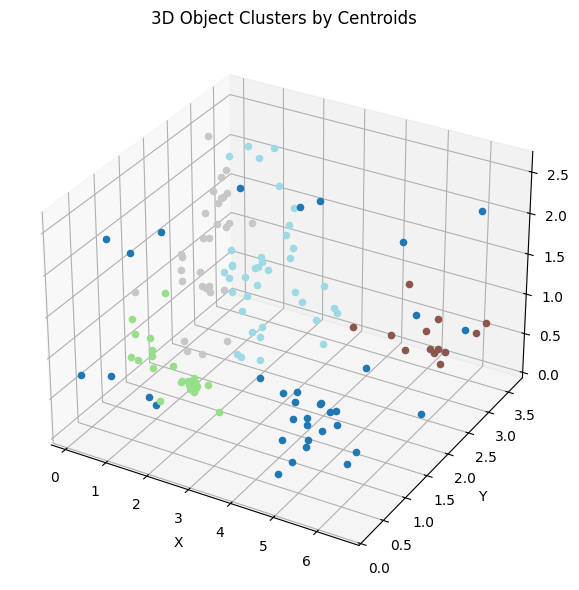

In [10]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
cmap = plt.get_cmap('tab20', max(object_to_regions.values()) + 1)

for obj_id, centroid in object_to_centroid.items():
    cluster_id = object_to_regions[obj_id]
    color = cmap(cluster_id)[:3]
    ax.scatter(*centroid, color=color, s=20)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
plt.title("3D Object Clusters by Centroids")
plt.tight_layout()
plt.savefig("object_clusters.png", dpi=300)

In [11]:
# Change: check the clustering
import plotly.graph_objects as go
import numpy as np

if object_to_regions:
    min_cluster_id = min(object_to_regions.values())
    max_cluster_id = max(object_to_regions.values())
    num_distinct_clusters = max_cluster_id - min_cluster_id + 1
else:
    min_cluster_id = 0
    num_distinct_clusters = 1 # Default to 1 if no regions are found

colors_cmap = plt.get_cmap('tab20', num_distinct_clusters)

x, y, z, color_list = [], [], [], []

for obj_id, centroid in object_to_centroid.items():
    x.append(centroid[0])
    y.append(centroid[1])
    z.append(centroid[2])

    cluster_id = object_to_regions.get(obj_id, min_cluster_id) # Use .get() with a default for robustness
    
    # Map the cluster_id to a 0-based index for the colormap
    # For example, if min_cluster_id is -1, then -1 becomes index 0, 0 becomes index 1, etc.
    color_index = cluster_id - min_cluster_id
    
    # Get the RGBA color from the colormap
    rgba_color = colors_cmap(color_index)
    
    # Format the color as a string suitable for Plotly's marker color
    # Plotly expects 'rgba(r,g,b,a)'
    color_list.append(f"rgba({int(rgba_color[0]*255)}, {int(rgba_color[1]*255)}, {int(rgba_color[2]*255)}, {rgba_color[3]})")

fig = go.Figure(data=[go.Scatter3d(
    x=x, y=y, z=z,
    mode='markers',
    marker=dict(size=4, color=color_list), # Use the correctly generated color_list
    text=[f'Object {obj_id}. Region {object_to_regions.get(obj_id, "N/A")}' for obj_id in object_to_centroid.keys()]
)])

fig.update_layout(
    title="3D Object Clusters (Interactive)",
    scene=dict(xaxis_title='X', yaxis_title='Y', zaxis_title='Z')
)
fig.show()
# k3d

In [18]:
with open('object_captions_latest_version.json', 'r') as f:
    object_captions = json.load(f)

In [20]:
for i in range(len(labels)):
    object_captions[i]['clustering_region'] = labels[i]

In [24]:
with open('object_captions_latest_version_1.json', 'w') as f:
    json.dump(object_captions, f, indent=4, default=lambda o: o.item() if hasattr(o, 'item') else str(o))

/home/vlm_caption/.local/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/home/vlm_caption/.local/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



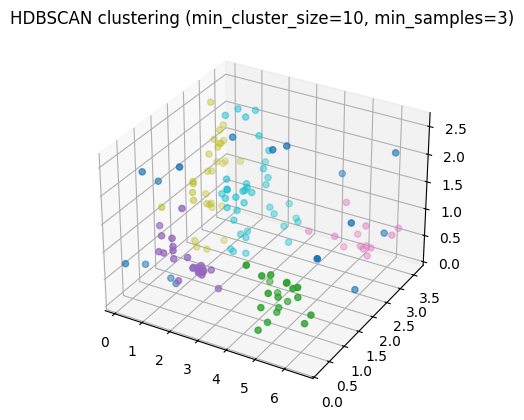

In [12]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

clusterer = hdbscan.HDBSCAN(min_cluster_size=10, min_samples=3)
labels = clusterer.fit_predict(centroids)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(centroids[:, 0], centroids[:, 1], centroids[:, 2], c=labels, cmap='tab10')
ax.set_title("HDBSCAN clustering (min_cluster_size=10, min_samples=3)")
plt.show()

In [14]:
# fig.write_html("clusters_plot.html")

In [15]:
from collections import Counter

value_counts = Counter(object_to_regions.values())
print(value_counts)

Counter({4: 38, 3: 30, 1: 23, 0: 20, -1: 16, 2: 13})


In [44]:
print(object_to_regions.get(139))

1


# 3. Combine the individual objects of each region together into submesh

In [17]:
from collections import defaultdict

cluster_to_mesh = defaultdict(o3d.geometry.TriangleMesh)

for obj_file in os.listdir(output_dir):
    if not obj_file.endswith('.ply'):
        continue
    obj_id = int(os.path.splitext(obj_file)[0].split("_")[1])
    cluster_id = object_to_regions[obj_id-1]
    
    mesh = o3d.io.read_triangle_mesh(os.path.join(output_dir, obj_file))
    cluster_to_mesh[cluster_id] += mesh  

In [41]:
for cluster_id, mesh in cluster_to_mesh.items():
    o3d.io.write_triangle_mesh(os.path.join(region_dir, f"merged_cluster_{cluster_id}.ply"), mesh)

# 4. Map the Region Mesh into 2D images

In [42]:
def read_cameras_text(path):
    cameras = {}
    with open(path, 'r') as f:
        for line in f:
            if line.startswith('#') or line.strip() == '':
                continue
            elems = line.strip().split()
            camera_id, model, width, height, fx, fy, cx, cy = elems[:8]
            cameras[int(camera_id)] = {
                'fx': float(fx), 'fy': float(fy), 'cx': float(cx), 'cy': float(cy),
                'width': int(width), 'height': int(height)
            }
    return cameras

def read_images_text(path):
    images = {}
    with open(path, 'r') as f:
        lines = f.readlines()

    i = 0
    while i < len(lines):
        line = lines[i].strip()
        if line.startswith("#") or line == "":
            i += 1
            continue
        elems = line.split()
        if len(elems) < 10:
            i += 1
            continue  # Skip invalid lines
        try:
            image_id = int(elems[0])
            qvec = np.array(list(map(float, elems[1:5])))
            tvec = np.array(list(map(float, elems[5:8])))
            camera_id = int(elems[8])
            image_name = elems[9]
            images[image_name] = {'qvec': qvec, 'tvec': tvec, 'camera_id': camera_id}
            i += 2  # Skip the following line (2D points) in COLMAP text format
        except ValueError:
            i += 1
            continue
    return images

def qvec2rotmat(qvec):
    w, x, y, z = qvec
    return np.array([
        [1-2*y**2-2*z**2, 2*x*y-2*z*w, 2*x*z+2*y*w],
        [2*x*y+2*z*w, 1-2*x**2-2*z**2, 2*y*z-2*x*w],
        [2*x*z-2*y*w, 2*y*z+2*x*w, 1-2*x**2-2*y**2]
    ])

In [83]:
cameras = read_cameras_text(os.path.join(colmap_dir, 'cameras.txt'))
images = read_images_text(os.path.join(colmap_dir, 'images.txt'))

# Save the projection area of all images for each obj
object_areas = defaultdict(list)

# Loop through all extracted regions
for obj_file in os.listdir(region_dir):
    if not obj_file.endswith('.ply'):
        continue
    obj_path = os.path.join(region_dir, obj_file)
    obj_mesh = o3d.io.read_triangle_mesh(obj_path)
    vertices = np.asarray(obj_mesh.vertices)
    print(f"Processing object: {obj_file}")

    for img_name, img_info in images.items():
        img_path = os.path.join(image_dir, img_name)
        if not os.path.exists(img_path):
            continue

        qvec, tvec, cam_id = img_info['qvec'], img_info['tvec'], img_info['camera_id']
        cam = cameras[cam_id]
        R = qvec2rotmat(qvec)
        t = np.array(tvec).reshape((3,1))
        K = np.array([[cam['fx'], 0, cam['cx']],
                      [0, cam['fy'], cam['cy']],
                      [0, 0, 1]])
        w, h = cam['width'], cam['height']

        # Make the projection from 3D to 2D
        verts_cam = (R @ vertices.T).T + t.T
        proj = (K @ verts_cam.T).T
        u, v, z = proj[:, 0] / proj[:, 2], proj[:, 1] / proj[:, 2], proj[:, 2]
        valid = (z > 0) & (u >= 0) & (u < w) & (v >= 0) & (v < h)
        if np.sum(valid) == 0:
            continue

        min_u, max_u = int(np.min(u[valid])), int(np.max(u[valid]))
        min_v, max_v = int(np.min(v[valid])), int(np.max(v[valid]))

        # padding
        padding = 0
        min_u = max(0, min_u - padding)
        max_u = min(w, max_u + padding)
        min_v = max(0, min_v - padding)
        max_v = min(h, max_v + padding)

        if max_u > min_u and max_v > min_v:
            area = (max_u - min_u) * (max_v - min_v)
            object_areas[obj_file].append((area, img_name, min_u, max_u, min_v, max_v))

            # Save all cropped images
            image = np.array(Image.open(img_path))
            crop = image[min_v:max_v, min_u:max_u]
            crop_name = f"{os.path.splitext(obj_file)[0]}_{os.path.splitext(img_name)[0]}.jpg"
            crop_path = os.path.join(region_crop_dir, crop_name)
            cv2.imwrite(crop_path, cv2.cvtColor(crop, cv2.COLOR_RGB2BGR))
        else:
            print(f"Skipping invalid crop for {img_name}")

for obj_file, views in object_areas.items():
    # extract Top-3 projections
    views_sorted = sorted(views, key=lambda x: x[0], reverse=True)
    top_5_view = views_sorted[:5]
    for area, img_name, min_u, max_u, min_v, max_v in top_5_view:
        img_path = os.path.join(image_dir, img_name)
        image = np.array(Image.open(img_path))
        crop = image[min_v:max_v, min_u:max_u]
        crop_name = f"{os.path.splitext(obj_file)[0]}_{os.path.splitext(img_name)[0]}.jpg"
        crop_path = os.path.join(region_top5_dir, crop_name)
        cv2.imwrite(crop_path, cv2.cvtColor(crop, cv2.COLOR_RGB2BGR))
        print(f"Saved top5 crop: {crop_name}")

    # extract Random 2 projections
    remaining_views = views_sorted[3:]

    if len(remaining_views) >= 3:
        random_views = random.sample(remaining_views, 2)
    else:
        random_views = remaining_views

    for area, img_name, min_u, max_u, min_v, max_v in random_views:
        img_path = os.path.join(image_dir, img_name)
        image = np.array(Image.open(img_path))
        crop = image[min_v:max_v, min_u:max_u]
        crop_name = f"{os.path.splitext(obj_file)[0]}_{os.path.splitext(img_name)[0]}_random.jpg"
        crop_path = os.path.join(region_top5_dir, crop_name)
        cv2.imwrite(crop_path, cv2.cvtColor(crop, cv2.COLOR_RGB2BGR))
        print(f"Saved random crop: {crop_name}")

Processing object: merged_cluster_2.ply
Processing object: merged_cluster_3.ply
Processing object: merged_cluster_4.ply
Processing object: merged_cluster_0.ply
Processing object: merged_cluster_-1.ply
Processing object: merged_cluster_1.ply
Saved top5 crop: merged_cluster_2_DSC06191.jpg
Saved top5 crop: merged_cluster_2_DSC06184.jpg
Saved top5 crop: merged_cluster_2_DSC06183.jpg
Saved top5 crop: merged_cluster_2_DSC06182.jpg
Saved top5 crop: merged_cluster_2_DSC06180.jpg
Saved random crop: merged_cluster_2_DSC05844_random.jpg
Saved random crop: merged_cluster_2_DSC05939_random.jpg
Saved top5 crop: merged_cluster_3_DSC06184.jpg
Saved top5 crop: merged_cluster_3_DSC05889.jpg
Saved top5 crop: merged_cluster_3_DSC05884.jpg
Saved top5 crop: merged_cluster_3_DSC05883.jpg
Saved top5 crop: merged_cluster_3_DSC05882.jpg
Saved random crop: merged_cluster_3_DSC05998_random.jpg
Saved random crop: merged_cluster_3_DSC05970_random.jpg
Saved top5 crop: merged_cluster_4_DSC06127.jpg
Saved top5 crop: m

# 5. Generate Caption for the region

In [59]:
from lmdeploy import pipeline, TurbomindEngineConfig, ChatTemplateConfig
from lmdeploy.vl.constants import IMAGE_TOKEN

model = 'OpenGVLab/InternVL3-2B'
pipe = pipeline(model, backend_config=TurbomindEngineConfig(session_len=16384, tp=1), chat_template_config=ChatTemplateConfig(model_name='internvl2_5'))

Fetching 20 files:   0%|          | 0/20 [00:00<?, ?it/s]

2025-06-10 14:00:45,940 - lmdeploy - WARNING - turbomind.py:252 - get 255 model params


[TM][WARNING] [LlamaTritonModel] `max_context_token_num` is not set, default to 16384.


2025-06-10 14:00:46,940 - lmdeploy - WARNING - tokenizer.py:499 - The token <|action_end|>, its length of indexes [27, 91, 1311, 6213, 91, 29] is over than 1. Currently, it can not be used as stop words


In [84]:
# Numbering images improves multi-image conversations
question = ''.join([f'Image-{i+1}: {IMAGE_TOKEN}\n' for i in range(5)])
question += '''
You are provided with the top-5 views of a specific region within a 3D scene. 
This region contains multiple objects that are spatially and functionally related.
First, come up with a brief title for the region. Then, provide a description of the region (not the scene), including its purpose or function.
After that, describe the relationships between the individual objects in detail — focusing on spatial arrangement, functional interaction, and contextual relevance.

The output format should be:
Region {Region Caption}
Region Description
Description between individual objects in the region with their relationships.
'''
print(question)

Image-1: <IMAGE_TOKEN>
Image-2: <IMAGE_TOKEN>
Image-3: <IMAGE_TOKEN>
Image-4: <IMAGE_TOKEN>
Image-5: <IMAGE_TOKEN>

You are provided with the top-5 views of a specific region within a 3D scene. 
This region contains multiple objects that are spatially and functionally related.
First, come up with a brief title for the region. Then, provide a description of the region (not the scene), including its purpose or function.
After that, describe the relationships between the individual objects in detail — focusing on spatial arrangement, functional interaction, and contextual relevance.

The output format should be:
Region {Region Caption}
Region Description
Description between individual objects in the region with their relationships.



In [89]:
folder_path = f'{scene_dir}/region_cropped_top5'
file_list = [f for f in os.listdir(folder_path) if os.path.isfile(os.path.join(folder_path, f))]

In [90]:
region_images = []
num_regions = np.max(list(object_to_regions.values()))
for i in range(num_regions+2):
    folder_path = f'{scene_dir}/region_cropped_top5'
    image_path = [f'{scene_dir}/region_cropped_top5/{path}' for path in file_list if f'cluster_{i-1}_' in path and 'random' not in path][:5]
    filename = os.path.basename(image_path[0])
    parts = filename.split('_')
    region = parts[2]
    region_images.append(
        {
            f'Region_{region}': image_path[:6]
        }
    )
print(region_images)

[{'Region_-1': ['ScanNet_Data/data/0a7cc12c0e/region_cropped_top5/merged_cluster_-1_DSC05899.jpg', 'ScanNet_Data/data/0a7cc12c0e/region_cropped_top5/merged_cluster_-1_DSC05895.jpg', 'ScanNet_Data/data/0a7cc12c0e/region_cropped_top5/merged_cluster_-1_DSC06179.jpg', 'ScanNet_Data/data/0a7cc12c0e/region_cropped_top5/merged_cluster_-1_DSC05898.jpg', 'ScanNet_Data/data/0a7cc12c0e/region_cropped_top5/merged_cluster_-1_DSC05897.jpg']}, {'Region_0': ['ScanNet_Data/data/0a7cc12c0e/region_cropped_top5/merged_cluster_0_DSC06157.jpg', 'ScanNet_Data/data/0a7cc12c0e/region_cropped_top5/merged_cluster_0_DSC06158.jpg', 'ScanNet_Data/data/0a7cc12c0e/region_cropped_top5/merged_cluster_0_DSC06161.jpg', 'ScanNet_Data/data/0a7cc12c0e/region_cropped_top5/merged_cluster_0_DSC06162.jpg', 'ScanNet_Data/data/0a7cc12c0e/region_cropped_top5/merged_cluster_0_DSC06160.jpg']}, {'Region_1': ['ScanNet_Data/data/0a7cc12c0e/region_cropped_top5/merged_cluster_1_DSC06127.jpg', 'ScanNet_Data/data/0a7cc12c0e/region_cropped_

In [91]:
region_captions = []
for i in range(len(region_images)):
    label, image_paths = next(iter(region_images[i].items()))
    images = [Image.open(path) for path in image_paths]
    response = pipe((question, images))
    region_captions.append({label:response.text})

In [ ]:
for cap in region_captions:
    k, v = next(iter(cap.items()))
    print(f'{k}:')
    print(f'{v}')
    print('-'*50)

Region_-1:
Region Title: Dormitory Study Area

Region Description:
This is a compact dormitory study area featuring a desk, chair, calendar, fan, and various personal items. The space is designed for study and minimal living, with a small kitchenette adjacent to the room.

Description between individual objects in the region:
- The desk is positioned against the wall, with a calendar hanging above it. The desk holds a laptop, mouse, books, and a water bottle, indicating a workspace.
- A fan is placed on the desk for comfort, and a small trash bin is underneath the desk for convenience.
- The chair is placed in front of the desk, suggesting it is used for studying or working.
- The open shelving under the desk contains various items, including clothes and books, indicating storage and organization.
- The adjacent kitchenette has a sink, countertop, and cabinets, providing a practical space for meals and cooking.
- The room has a bed with a colorful blanket, indicating a sleeping area.
-

: 